In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kendalltau, kstest
from sklearn.metrics import roc_auc_score, average_precision_score

# ----------------------------
# Paths
# ----------------------------
RES_DIR = "./results/sim"
MG_DIR = os.path.join(RES_DIR, "moran_geary")
SPARKX_DIR = os.path.join(RES_DIR, "SparkX")
SOMDE_DIR = os.path.join(RES_DIR, "somDE")

OUT_DIR = os.path.join(RES_DIR, "combined_eval")
os.makedirs(OUT_DIR, exist_ok=True)

difficulties = ["easy", "medium", "hard"]

# ----------------------------
# Load files
# ----------------------------
def load_moran_geary(diff):
    moran = pd.read_csv(os.path.join(MG_DIR, f"{diff}_moran_per_gene.csv"), index_col=0)
    geary = pd.read_csv(os.path.join(MG_DIR, f"{diff}_geary_per_gene.csv"), index_col=0)
    return moran, geary

def load_sparkx(diff):
    df = pd.read_csv(os.path.join(SPARKX_DIR, f"sparkx_all_{diff}.csv"), index_col=0)
    return df

def load_somde(diff):
    df = pd.read_csv(os.path.join(SOMDE_DIR, f"sim_{diff}_somde_results.csv"))
    if "g" in df.columns:
        df = df.set_index("g")
    return df

# ----------------------------
# Helpers
# ----------------------------
def safe_log10p(p, eps=1e-300):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0)
    return -np.log10(p)

def evaluate(score, truth):
    score = np.asarray(score, dtype=float)
    truth = np.asarray(truth, dtype=int)

    ok = np.isfinite(score)
    score = score[ok]
    truth = truth[ok]

    tau = kendalltau(score, truth).statistic
    auroc = roc_auc_score(truth, score)
    auprc = average_precision_score(truth, score)

    return tau, auroc, auprc

def ks_uniform(pvals):
    pvals = np.asarray(pvals, dtype=float)
    pvals = pvals[np.isfinite(pvals)]
    return kstest(pvals, "uniform").statistic

def qq_plot(pvals_dict, title, outpath):
    plt.figure(figsize=(6,6))
    for diff, pvals in pvals_dict.items():
        p = np.sort(pvals)
        n = len(p)
        exp = (np.arange(1, n+1)-0.5)/n
        plt.plot(exp, p, label=diff)

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("Expected Uniform")
    plt.ylabel("Observed p-values")
    plt.title(title)
    plt.legend()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close()

# ----------------------------
# Main evaluation
# ----------------------------
rows = []
qq_vals = {"Moran":{}, "Geary":{}, "SPARK-X":{}, "SOMDE":{}}

for diff in difficulties:

    moran, geary = load_moran_geary(diff)
    sparkx = load_sparkx(diff)
    somde = load_somde(diff)

    # -----------------------------------
    # Moran
    # -----------------------------------
    tau, auroc, auprc = evaluate(moran["I"], moran["is_spatial"])
    null_p = moran.loc[moran["is_spatial"]==0, "pval_sim"]
    ks = ks_uniform(null_p)

    qq_vals["Moran"][diff] = null_p.values

    rows.append(dict(difficulty=diff, method="Moran",
                     kendall_tau=tau, auroc=auroc,
                     auprc=auprc, ks_null=ks))

    # -----------------------------------
    # Geary (-C)
    # -----------------------------------
    tau, auroc, auprc = evaluate(-geary["C"], geary["is_spatial"])
    null_p = geary.loc[geary["is_spatial"]==0, "pval_sim"]
    ks = ks_uniform(null_p)

    qq_vals["Geary"][diff] = null_p.values

    rows.append(dict(difficulty=diff, method="Geary (-C)",
                     kendall_tau=tau, auroc=auroc,
                     auprc=auprc, ks_null=ks))

    # -----------------------------------
    # SPARK-X
    # -----------------------------------
    sparkx = sparkx.join(moran[["is_spatial","pattern_type"]])
    score = safe_log10p(sparkx["combinedPval"])

    tau, auroc, auprc = evaluate(score, sparkx["is_spatial"])
    null_p = sparkx.loc[sparkx["is_spatial"]==0, "combinedPval"]
    ks = ks_uniform(null_p)

    qq_vals["SPARK-X"][diff] = null_p.values

    rows.append(dict(difficulty=diff, method="SPARK-X (-log10 p)",
                     kendall_tau=tau, auroc=auroc,
                     auprc=auprc, ks_null=ks))

    # -----------------------------------
    # SOMDE
    # -----------------------------------
    somde = somde.join(moran[["is_spatial","pattern_type"]])
    score = somde["FSV"]

    tau, auroc, auprc = evaluate(score, somde["is_spatial"])

    if "pval" in somde.columns:
        null_p = somde.loc[somde["is_spatial"]==0, "pval"]
        ks = ks_uniform(null_p)
        qq_vals["SOMDE"][diff] = null_p.values
    else:
        ks = np.nan

    rows.append(dict(difficulty=diff, method="SOMDE (FSV)",
                     kendall_tau=tau, auroc=auroc,
                     auprc=auprc, ks_null=ks))

# ----------------------------
# Save results
# ----------------------------
results = pd.DataFrame(rows)
results.to_csv(os.path.join(OUT_DIR,"method_comparison.csv"), index=False)
print(results)

# QQ plots
for method in qq_vals:
    qq_plot(qq_vals[method],
            f"QQ plot of null p-values ({method})",
            os.path.join(OUT_DIR, f"qq_{method}.png"))

   difficulty              method  kendall_tau     auroc     auprc   ks_null
0        easy               Moran     0.708288  1.000000  1.000000  0.872394
1        easy          Geary (-C)     0.708288  1.000000  1.000000  0.878388
2        easy  SPARK-X (-log10 p)     0.636641  0.949422  0.962980  0.846485
3        easy         SOMDE (FSV)     0.325994  0.729622  0.616934  0.176105
4      medium               Moran     0.687071  0.985022  0.989172  0.508798
5      medium          Geary (-C)     0.683482  0.982489  0.987404  0.517463
6      medium  SPARK-X (-log10 p)     0.546547  0.885822  0.923442  0.135964
7      medium         SOMDE (FSV)     0.311538  0.716911  0.584598  0.434213
8        hard               Moran     0.516326  0.864489  0.898810  0.500500
9        hard          Geary (-C)     0.477544  0.837111  0.881363  0.502498
10       hard  SPARK-X (-log10 p)     0.383798  0.770933  0.820311  0.100035
11       hard         SOMDE (FSV)     0.235231  0.663733  0.571660  0.380990

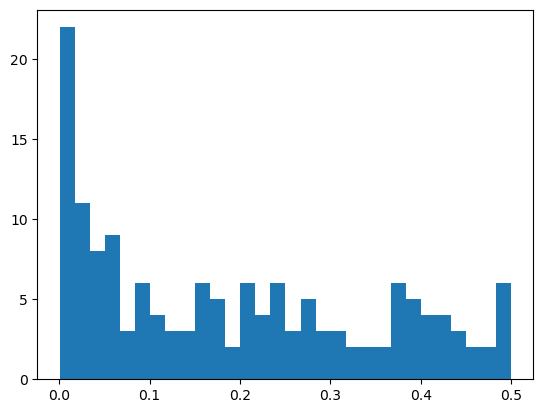

In [5]:
null_p = moran.loc[moran["is_spatial"]==0, "pval_sim"]
plt.hist(null_p, bins=30)
plt.show()

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kendalltau, kstest
from sklearn.metrics import roc_auc_score, average_precision_score

# ----------------------------
# Paths
# ----------------------------
RES_DIR = "./results/sim"
MG_DIR = os.path.join(RES_DIR, "moran_geary")
SPARKX_DIR = os.path.join(RES_DIR, "SparkX")
SOMDE_DIR = os.path.join(RES_DIR, "somDE")
SPATIALDE_DIR = os.path.join(RES_DIR, "spatialde")   # <-- NEW

OUT_DIR = os.path.join(RES_DIR, "combined_eval")
os.makedirs(OUT_DIR, exist_ok=True)

difficulties = ["easy", "medium", "hard"]

# ----------------------------
# Load files
# ----------------------------
def load_moran_geary(diff):
    moran = pd.read_csv(os.path.join(MG_DIR, f"{diff}_moran_per_gene.csv"), index_col=0)
    geary = pd.read_csv(os.path.join(MG_DIR, f"{diff}_geary_per_gene.csv"), index_col=0)
    return moran, geary

def load_sparkx(diff):
    return pd.read_csv(os.path.join(SPARKX_DIR, f"sparkx_all_{diff}.csv"), index_col=0)

def load_somde(diff):
    df = pd.read_csv(os.path.join(SOMDE_DIR, f"sim_{diff}_somde_results.csv"))
    if "g" in df.columns:
        df = df.set_index("g")
    return df

def load_spatialde(diff):   # <-- NEW
    # files are like: sim_easy_spatialde_results.csv
    df = pd.read_csv(os.path.join(SPATIALDE_DIR, f"sim_{diff}_spatialde_results.csv"))
    if "g" in df.columns:
        df = df.set_index("g")
    return df

# ----------------------------
# Helpers
# ----------------------------
def safe_log10p(p, eps=1e-300):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0)
    return -np.log10(p)

def evaluate(score, truth):
    score = np.asarray(score, dtype=float)
    truth = np.asarray(truth, dtype=int)

    ok = np.isfinite(score)
    score = score[ok]
    truth = truth[ok]

    tau = kendalltau(score, truth).statistic
    auroc = roc_auc_score(truth, score)
    auprc = average_precision_score(truth, score)

    return tau, auroc, auprc

def ks_uniform(pvals):
    pvals = np.asarray(pvals, dtype=float)
    pvals = pvals[np.isfinite(pvals)]
    if len(pvals) == 0:
        return np.nan
    return kstest(pvals, "uniform").statistic

def qq_plot(pvals_dict, title, outpath):
    plt.figure(figsize=(6, 6))
    for diff, pvals in pvals_dict.items():
        p = np.asarray(pvals, dtype=float)
        p = p[np.isfinite(p)]
        if len(p) == 0:
            continue
        p = np.sort(p)
        n = len(p)
        exp = (np.arange(1, n + 1) - 0.5) / n
        plt.plot(exp, p, label=diff)

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("Expected Uniform")
    plt.ylabel("Observed p-values")
    plt.title(title)
    plt.legend()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close()

# ----------------------------
# Main evaluation
# ----------------------------
rows = []
qq_vals = {"Moran": {}, "Geary": {}, "SPARK-X": {}, "SOMDE": {}, "SpatialDE": {}}  # <-- NEW

for diff in difficulties:

    moran, geary = load_moran_geary(diff)
    sparkx = load_sparkx(diff)
    somde = load_somde(diff)
    spatialde = load_spatialde(diff)   # <-- NEW

    # -----------------------------------
    # Moran
    # -----------------------------------
    tau, auroc, auprc = evaluate(moran["I"], moran["is_spatial"])
    null_p = moran.loc[moran["is_spatial"] == 0, "pval_sim"]
    ks = ks_uniform(null_p)
    qq_vals["Moran"][diff] = null_p.values

    rows.append(dict(difficulty=diff, method="Moran",
                     kendall_tau=tau, auroc=auroc, auprc=auprc, ks_null=ks))

    # -----------------------------------
    # Geary (-C)
    # -----------------------------------
    tau, auroc, auprc = evaluate(-geary["C"], geary["is_spatial"])
    null_p = geary.loc[geary["is_spatial"] == 0, "pval_sim"]
    ks = ks_uniform(null_p)
    qq_vals["Geary"][diff] = null_p.values

    rows.append(dict(difficulty=diff, method="Geary (-C)",
                     kendall_tau=tau, auroc=auroc, auprc=auprc, ks_null=ks))

    # -----------------------------------
    # SPARK-X
    # -----------------------------------
    sparkx = sparkx.join(moran[["is_spatial"]])  # label source
    score = safe_log10p(sparkx["combinedPval"])

    tau, auroc, auprc = evaluate(score, sparkx["is_spatial"])
    null_p = sparkx.loc[sparkx["is_spatial"] == 0, "combinedPval"]
    ks = ks_uniform(null_p)
    qq_vals["SPARK-X"][diff] = null_p.values

    rows.append(dict(difficulty=diff, method="SPARK-X (-log10 p)",
                     kendall_tau=tau, auroc=auroc, auprc=auprc, ks_null=ks))

    # -----------------------------------
    # SOMDE
    # -----------------------------------
    somde = somde.join(moran[["is_spatial"]])
    score = somde["FSV"]

    tau, auroc, auprc = evaluate(score, somde["is_spatial"])

    if "pval" in somde.columns:
        null_p = somde.loc[somde["is_spatial"] == 0, "pval"]
        ks = ks_uniform(null_p)
        qq_vals["SOMDE"][diff] = null_p.values
    else:
        ks = np.nan

    rows.append(dict(difficulty=diff, method="SOMDE (FSV)",
                     kendall_tau=tau, auroc=auroc, auprc=auprc, ks_null=ks))

    # -----------------------------------
    # SpatialDE  (NEW)
    # -----------------------------------
    spatialde = spatialde.join(moran[["is_spatial"]])

    # ranking score: FSV (higher -> more spatial)
    score = spatialde["FSV"]
    tau, auroc, auprc = evaluate(score, spatialde["is_spatial"])

    # null calibration: pval column
    if "pval" in spatialde.columns:
        null_p = spatialde.loc[spatialde["is_spatial"] == 0, "pval"]
        ks = ks_uniform(null_p)
        qq_vals["SpatialDE"][diff] = null_p.values
    else:
        ks = np.nan

    rows.append(dict(difficulty=diff, method="SpatialDE (FSV)",
                     kendall_tau=tau, auroc=auroc, auprc=auprc, ks_null=ks))

# ----------------------------
# Save results
# ----------------------------
results = pd.DataFrame(rows)
results.to_csv(os.path.join(OUT_DIR, "method_comparison.csv"), index=False)
print(results)

# QQ plots
for method in qq_vals:
    qq_plot(qq_vals[method],
            f"QQ plot of null p-values ({method})",
            os.path.join(OUT_DIR, f"qq_{method}.png"))

   difficulty              method  kendall_tau     auroc     auprc   ks_null
0        easy               Moran     0.708288  1.000000  1.000000  0.872394
1        easy          Geary (-C)     0.708288  1.000000  1.000000  0.878388
2        easy  SPARK-X (-log10 p)     0.636641  0.949422  0.962980  0.846485
3        easy         SOMDE (FSV)     0.325994  0.729622  0.616934  0.176105
4        easy     SpatialDE (FSV)     0.251246  0.676000  0.546784  0.481886
5      medium               Moran     0.687071  0.985022  0.989172  0.508798
6      medium          Geary (-C)     0.683482  0.982489  0.987404  0.517463
7      medium  SPARK-X (-log10 p)     0.546547  0.885822  0.923442  0.135964
8      medium         SOMDE (FSV)     0.311538  0.716911  0.584598  0.434213
9      medium     SpatialDE (FSV)     0.207850  0.645222  0.530663  0.475590
10       hard               Moran     0.516326  0.864489  0.898810  0.500500
11       hard          Geary (-C)     0.477544  0.837111  0.881363  0.502498

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Results table
# ----------------------------
data = [
    ("Easy","Moran",0.708,1.000,1.000,0.872),
    ("Easy","Geary (-C)",0.708,1.000,1.000,0.878),
    ("Easy","SPARK-X",0.637,0.949,0.963,0.846),
    ("Easy","SOMDE",0.326,0.730,0.617,0.176),
    ("Easy","SpatialDE",0.251,0.676,0.547,0.482),

    ("Medium","Moran",0.687,0.985,0.989,0.509),
    ("Medium","Geary (-C)",0.683,0.982,0.987,0.517),
    ("Medium","SPARK-X",0.547,0.886,0.923,0.136),
    ("Medium","SOMDE",0.312,0.717,0.585,0.434),
    ("Medium","SpatialDE",0.208,0.645,0.531,0.476),

    ("Hard","Moran",0.516,0.864,0.899,0.501),
    ("Hard","Geary (-C)",0.478,0.837,0.881,0.502),
    ("Hard","SPARK-X",0.384,0.771,0.820,0.100),
    ("Hard","SOMDE",0.235,0.664,0.572,0.381),
    ("Hard","SpatialDE",0.101,0.570,0.514,0.522),
]

df = pd.DataFrame(data, columns=[
    "Difficulty","Method","Kendall_tau","AUROC","AUPRC","KS"
])

methods = df["Method"].unique()
difficulties = ["Easy","Medium","Hard"]

# Consistent muted palette
colors = {
    "Easy":   "#4C72B0",
    "Medium": "#DD8452",
    "Hard":   "#55A868",
}

def plot_metric(metric, ylabel, filename):
    x = np.arange(len(methods))
    width = 0.25

    plt.figure(figsize=(9,4))  # wider, cleaner for slides

    for i, diff in enumerate(difficulties):
        vals = df[df["Difficulty"]==diff][metric].values
        plt.bar(x + i*width, vals, width,
                label=diff,
                color=colors[diff])

    plt.xticks(x + width, methods, rotation=40, ha="right")
    plt.ylabel(ylabel)
    plt.title(ylabel + " across difficulty levels")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()

# Generate three separate vertical figures
plot_metric("Kendall_tau", "Kendall τ", "kendall_tau_plot.png")
plot_metric("AUROC", "AUROC", "auroc_plot.png")
plot_metric("KS", "KS (null)", "ks_plot.png")

print("Plots saved.")

Plots saved.
